# 비지도 학습: 군집화 3종 비교 (K-Means / DBSCAN / GMM)

라벨 없이 데이터의 구조를 찾아내는 대표적인 군집화 알고리즘 세 가지를 같은 데이터에 적용해 강·약점을 비교합니다.

## 학습 목표
- 표준 분포 vs 기울어진 분포에서 K-Means 의 한계 관찰
- **DBSCAN** 의 밀도 기반 군집화 — `eps`, `min_samples` 의 의미
- **GMM** 의 가우시안 혼합 모델 — 평균/공분산 추정과 소프트 할당
- 데이터 분포 형태에 맞는 알고리즘 선택 감각

## 사용 라이브러리
`numpy`, `matplotlib`, `scikit-learn`

## 2. K-Means

데이터를 K 개의 군집으로 나누고 각 군집의 **중심(centroid)** 까지 거리 합을 최소화합니다. 군집 모양이 **구형(원형)** 이라는 가정이 강해, 길쭉하거나 기울어진 분포에서는 성능이 떨어집니다.

| 파라미터 | 의미 |
|---|---|
| `n_clusters` | 군집의 개수 K (사전에 알아야 함) |
| `random_state` | 초기 중심 선택의 시드 — 결과 재현용 |

`make_blobs` 로 3개 군집의 표준 분포(`X_1`)와 행렬 변환으로 기울어진 분포(`X_2`) 두 가지 데이터를 만들어 비교합니다.

In [1]:


# Author: Phil Roth <mr.phil.roth@gmail.com>
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 1000
random_state = 200

X_1, y_1 = make_blobs(n_samples=n_samples, random_state=random_state)

# 기울어진 데이터 분포
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_2 = np.dot(X_1, transformation)



### 데이터 미리보기

원본(`X_1`)과 변환된 분포(`X_2`)를 산점도로 비교합니다. K-Means 가 어떤 분포에 강한지 직관적으로 확인하기 위함입니다.

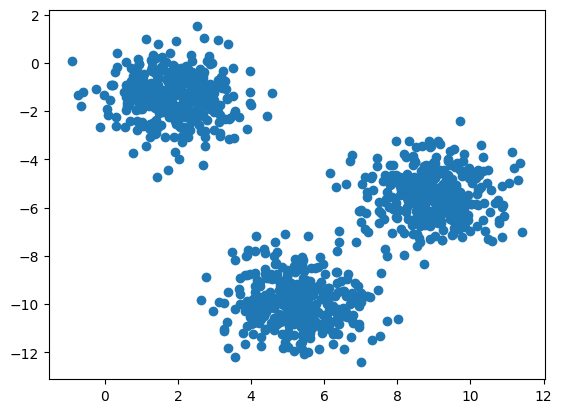

In [2]:

plt.scatter(X_1[:, 0], X_1[:, 1])



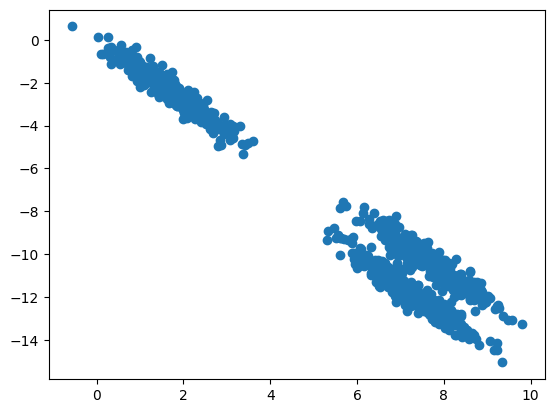

In [3]:
plt.scatter(X_2[:, 0], X_2[:, 1])

### K-Means 군집화 결과

`KMeans(n_clusters=3)` 로 두 데이터(`X_1`, `X_2`)를 각각 군집화합니다. 구형 군집은 잘 잡지만 **기울어진 분포** 에서는 K-Means 의 한계가 드러납니다 (다음 절 GMM 비교).

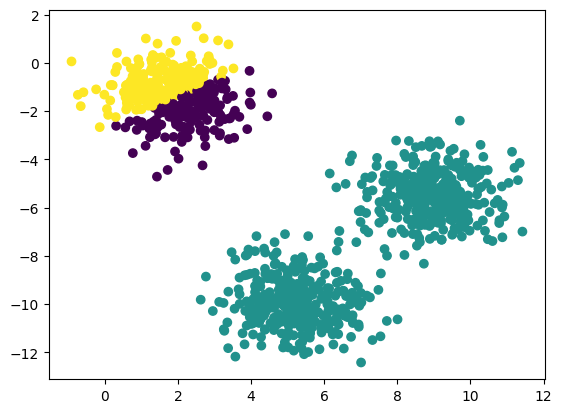

In [4]:

from sklearn.cluster import KMeans

y_pred_1 = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_1)

plt.scatter(X_1[:, 0], X_1[:, 1], c=y_pred_1)

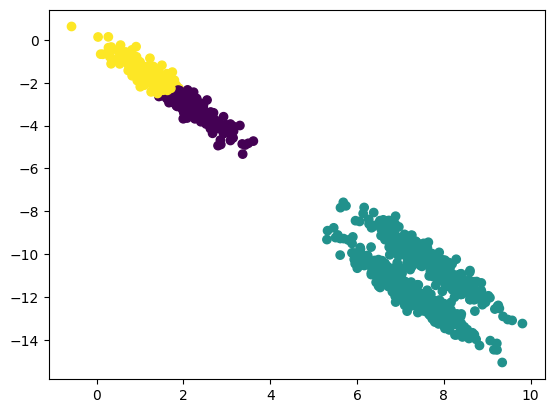

In [5]:

y_pred_2 = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_2)

plt.scatter(X_2[:, 0], X_2[:, 1], c=y_pred_2)

## 3. DBSCAN

**밀도 기반** 군집화로, 임의의 모양과 잡음(noise) 점을 다룰 수 있습니다. 군집 개수를 미리 정할 필요 없이 데이터 밀도에 따라 자동으로 형성됩니다.

| 파라미터 | 의미 |
|---|---|
| `eps` | 이웃으로 간주할 최대 거리 |
| `min_samples` | 핵심점(core point)이 되기 위한 이웃 최소 개수 |

라벨 `-1` 은 어떤 군집에도 속하지 못한 **잡음(outlier)** 입니다.

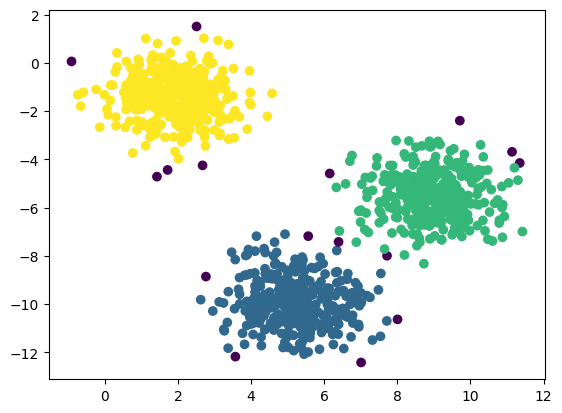

In [6]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.8, min_samples=10).fit(X_1)

plt.scatter(X_1[:, 0], X_1[:, 1], c=clustering.labels_)

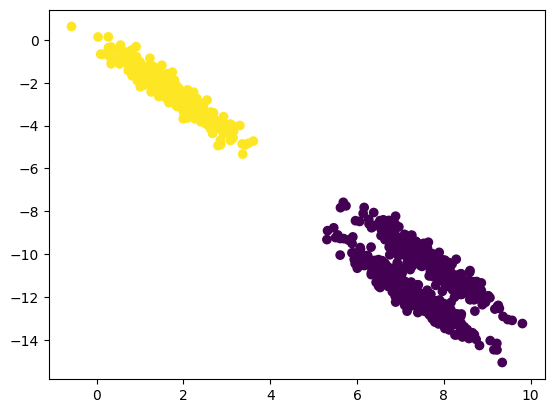

In [7]:
clustering = DBSCAN(eps=0.8, min_samples=7).fit(X_2)

plt.scatter(X_2[:, 0], X_2[:, 1], c=clustering.labels_)


## 4. GMM (Gaussian Mixture Model)

데이터가 K 개의 **가우시안 분포의 혼합** 으로 생성되었다고 가정하고, EM 알고리즘으로 각 분포의 평균/공분산/혼합비율을 추정합니다. K-Means 와 달리 **타원형 (방향성 있는)** 군집을 다룰 수 있어 기울어진 분포에 강합니다.

| 항목 | K-Means | GMM |
|---|---|---|
| 군집 모양 | 구형(거리 기반) | 타원형(공분산 행렬) |
| 할당 방식 | 하드(가장 가까운 1개) | 소프트(클래스별 확률) |
| 출력 | 중심점만 | 평균 + 공분산 + 혼합비율 |

mu:   [[ 5.2043374  -9.92174516]
 [ 1.88570795 -1.38815406]
 [ 8.95616825 -5.47369952]]
std:  [[[ 0.92692011 -0.07471284]
  [-0.07471284  1.03821394]]

 [[ 0.87646782 -0.05710937]
  [-0.05710937  0.956162  ]]

 [[ 0.91428984 -0.00343821]
  [-0.00343821  0.99715565]]]


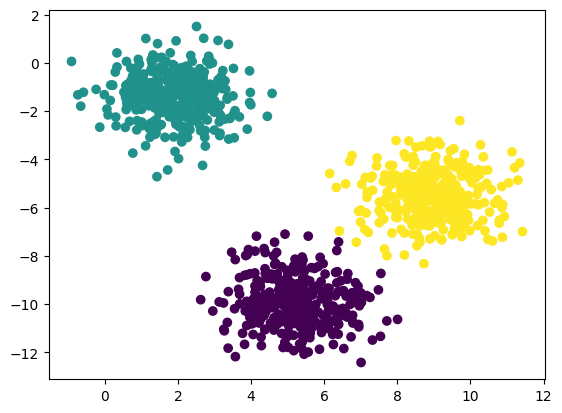

In [8]:

from sklearn.mixture import GaussianMixture

gm_1 = GaussianMixture(n_components=3, random_state=0).fit(X_1)
labels_1 = gm_1.predict(X_1)

print('mu:  ', gm_1.means_)
print('std: ', gm_1.covariances_)

plt.scatter(X_1[:, 0], X_1[:, 1], c=labels_1)


mu:   [[  7.68681294 -10.36830372]
 [  1.71474645  -2.38402629]
 [  7.22287062 -11.77134263]]
std:  [[[ 0.50683433 -0.70476031]
  [-0.70476031  1.09933124]]

 [[ 0.51262972 -0.71725611]
  [-0.71725611  1.11222436]]

 [[ 0.55357478 -0.77876035]
  [-0.77876035  1.21160939]]]


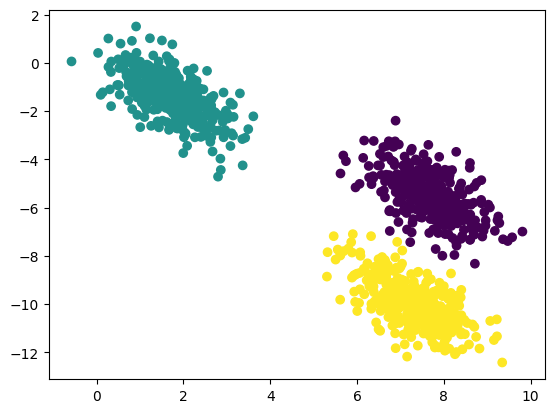

In [9]:
gm_2 = GaussianMixture(n_components=3, random_state=0).fit(X_2)
labels_2 = gm_2.predict(X_2)

print('mu:  ', gm_2.means_)

print('std: ', gm_2.covariances_)

plt.scatter(X_2[:, 0], X_1[:, 1], c=labels_2)